#Data Cleaning

In [1]:
# data loading
import pandas as pd
import seaborn as sns
%matplotlib inline
df  = pd.read_csv('text_data_vodacom.csv')

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24903 entries, 0 to 24902
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Conversation Stream       23267 non-null  str    
 1   Sender Profile Image Url  24552 non-null  str    
 2   Created Time              24903 non-null  str    
 3   Permalink                 22812 non-null  str    
 4   snTypeColumn              24903 non-null  str    
 5   Associated Cases          21602 non-null  float64
 6   Sentiment                 24903 non-null  str    
 7   Mentions (SUM)            24903 non-null  int64  
dtypes: float64(1), int64(1), str(6)
memory usage: 1.5 MB


In [3]:
df.head()

,Conversation Stream,Sender Profile Image Url,Created Time,Permalink,snTypeColumn,Associated Cases,Sentiment,Mentions (SUM)
0,How to get puk code,https://platform-lookaside.fbsbx.com/platform/...,2026-05-20 23:36:55,https://www.facebook.com/702913781873469/posts...,FACEBOOK,1373738.0,Neutral,1
1,Il y a un numéro Vodacom qui m&#39;a envoyé 85...,https://platform-lookaside.fbsbx.com/platform/...,2026-05-21 03:10:31,https://www.facebook.com/702913781873469/video...,FACEBOOK,1373878.0,Negative,1
2,So I see vodacom has become useless since the ...,https://platform-lookaside.fbsbx.com/platform/...,2026-05-20 11:47:05,https://www.facebook.com/702913781873469/video...,FACEBOOK,1372992.0,Negative,1
3,NaN,https://platform-lookaside.fbsbx.com/platform/...,2026-05-23 00:53:20,https://www.facebook.com/702913781873469/video...,FACEBOOK,1376757.0,Uncategorized,1
4,I am scammed.\nI did not see the sms on time. ...,https://platform-lookaside.fbsbx.com/platform/...,2026-05-24 22:58:07,https://www.facebook.com/702913781873469/posts...,FACEBOOK,1380197.0,Negative,1


In [4]:
df.iloc[0] #first row

Conversation Stream                                       How to get puk code
Sender Profile Image Url    https://platform-lookaside.fbsbx.com/platform/...
Created Time                                              2026-05-20 23:36:55
Permalink                   https://www.facebook.com/702913781873469/posts...
snTypeColumn                                                         FACEBOOK
Associated Cases                                                    1373738.0
Sentiment                                                             Neutral
Mentions (SUM)                                                              1
Name: 0, dtype: object

In [5]:
## Checking the distribution of sentiment, this tells me the data is not correctly balanced.
# Need to ensure uniformaty
df.pivot_table(index = "Sentiment", aggfunc="size")


Sentiment
Negative          3944
Neutral          11735
Positive          7592
Uncategorized     1632
dtype: int64

In [6]:
#same function
df.groupby('Sentiment').size().sort_values(ascending=False)

Sentiment
Neutral          11735
Positive          7592
Negative          3944
Uncategorized     1632
dtype: int64

In [7]:
# How many NA values are there in a dataframe
df['Conversation Stream'].isna().groupby(df['Sentiment']).sum()

Sentiment
Negative            0
Neutral             5
Positive            0
Uncategorized    1631
Name: Conversation Stream, dtype: int64

In [8]:
# How many NA values are there in a dataframe
df.groupby('Sentiment')['Conversation Stream'].apply(lambda x: x.isna().sum()).sort_values(ascending=False)

Sentiment
Uncategorized    1631
Neutral             5
Negative            0
Positive            0
Name: Conversation Stream, dtype: int64

In [9]:
#Overall NA values
df['Conversation Stream'].notna().value_counts()

Conversation Stream
True     23267
False     1636
Name: count, dtype: int64

In [10]:
#Removing unnecessary columns & dropping NA values
df_cleaned = df.drop(labels=['Sender Profile Image Url', 'Permalink', 'Associated Cases', 'Mentions (SUM)'], axis = 1).dropna()
df_cleaned

,Conversation Stream,Created Time,snTypeColumn,Sentiment
0,How to get puk code,2026-05-20 23:36:55,FACEBOOK,Neutral
1,Il y a un numéro Vodacom qui m&#39;a envoyé 85...,2026-05-21 03:10:31,FACEBOOK,Negative
2,So I see vodacom has become useless since the ...,2026-05-20 11:47:05,FACEBOOK,Negative
4,I am scammed.\nI did not see the sms on time. ...,2026-05-24 22:58:07,FACEBOOK,Negative
5,I need airtime in advance I&#39;m stuck on the...,2026-05-20 06:45:22,FACEBOOK,Negative
...,...,...,...,...
24898,Danko boy 😂,2026-05-24 16:42:00,YOUTUBE,Positive
24899,Hi i got my fibre today but didn't receive any...,2026-05-25 19:27:35,YOUTUBE,Negative
24900,✌️✌️✌️✌️✌️✌️✌️✌️✌️✌️,2026-05-24 10:48:55,YOUTUBE,Positive
24901,I love the fact that you never wanted to do in...,2026-05-19 12:31:05,YOUTUBE,Positive


In [11]:
#Source of messages
df_cleaned.groupby("snTypeColumn").size()

snTypeColumn
FACEBOOK     15969
INSTAGRAM      744
LINKEDIN        75
TIKTOK          58
TWITTER       6392
YOUTUBE         29
dtype: int64

In [12]:
#Inspect distribution, now that NA values have been handled
df_cleaned.groupby("Sentiment").size()

Sentiment
Negative          3944
Neutral          11730
Positive          7592
Uncategorized        1
dtype: int64

In [13]:
df_cleaned.head()

,Conversation Stream,Created Time,snTypeColumn,Sentiment
0,How to get puk code,2026-05-20 23:36:55,FACEBOOK,Neutral
1,Il y a un numéro Vodacom qui m&#39;a envoyé 85...,2026-05-21 03:10:31,FACEBOOK,Negative
2,So I see vodacom has become useless since the ...,2026-05-20 11:47:05,FACEBOOK,Negative
4,I am scammed.\nI did not see the sms on time. ...,2026-05-24 22:58:07,FACEBOOK,Negative
5,I need airtime in advance I&#39;m stuck on the...,2026-05-20 06:45:22,FACEBOOK,Negative


In [14]:
#Remove uncategorised entirely from the df
sent = df_cleaned['Sentiment'].value_counts().head(3).index
# sent = ['Positive', 'Negative', 'Neutral']
# create a new df without the uncategorised data, will call it df_sent
df_sent = df_cleaned[df_cleaned['Sentiment'].isin(sent)]

print('Length of df_cleaned:               ', len(df_cleaned))
print('Length of df_sent:                ', len(df_sent))
print('Rows Dropped ', len(df_cleaned) - len(df_sent))

Length of df_cleaned:                23267
Length of df_sent:                 23266
Rows Dropped  1


In [15]:
import matplotlib.pyplot as plt

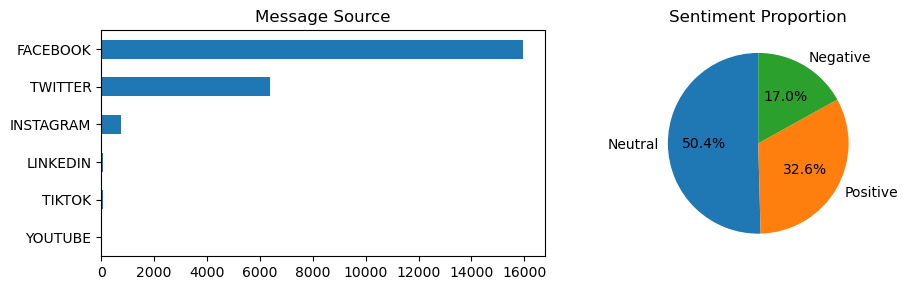

In [16]:
fig, ax = plt.subplots(1,2, figsize = (10,3))

df_sent['snTypeColumn'].value_counts().plot(kind='barh', ax=ax[0],title="Message Source")
ax[0].invert_yaxis()
ax[0].set_ylabel('')

df_sent['Sentiment'].value_counts().plot(kind='pie', startangle = 90, autopct = '%1.1f%%', ax=ax[1], title="Sentiment Proportion")

fig.tight_layout()
plt.show()

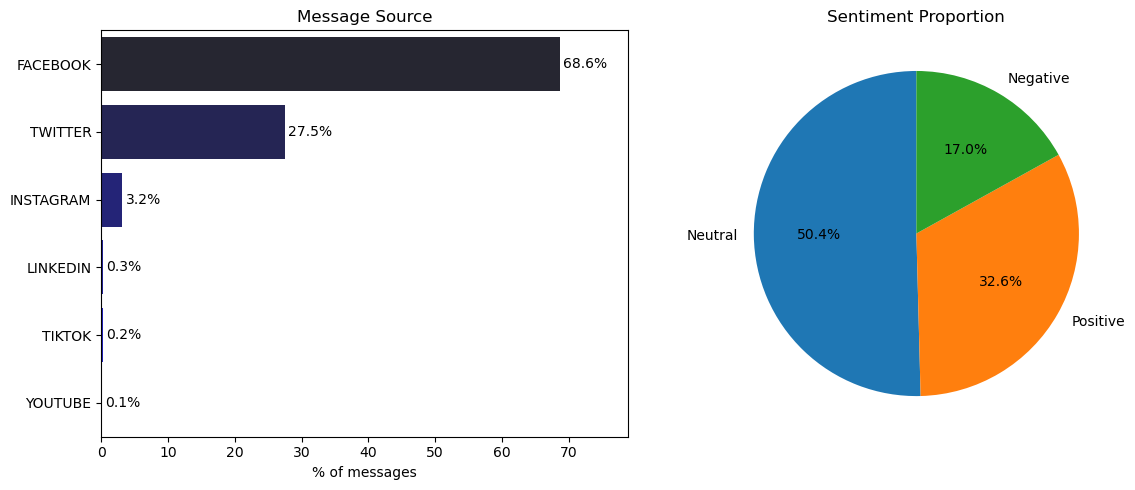

In [17]:
# Whats the distibution of negative, positive and neutral messages. 
# Before we pass the data for ML we need to understand messages distribution, 
# This helps to ensure that our model was trained fairly

platform_counts = df_sent['snTypeColumn'].value_counts()
platform_pct = (platform_counts / platform_counts.sum() * 100).reset_index()
platform_pct.columns = ['Platform', 'percentage']
platform_pct = platform_pct.sort_values('percentage', ascending=True)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=platform_pct, x='percentage', y='Platform', ax=ax[0], hue='Platform', palette='dark:b_r', legend=False)
ax[0].set_title('Message Source')
ax[0].set_xlabel('% of messages')
ax[0].set_ylabel('')
ax[0].set_xlim(0, platform_pct['percentage'].max() * 1.15)
ax[0].invert_yaxis()

for n, v in enumerate(platform_pct['percentage']):
    ax[0].text(v + 0.5, n, f'{v:.1f}%', va='center')

df_sent['Sentiment'].value_counts().plot(kind='pie', startangle=90, autopct='%1.1f%%', ax=ax[1], ylabel='', title='Sentiment Proportion')

fig.tight_layout()
plt.show()

In [18]:
df_Plat = df_sent.groupby(['Sentiment','snTypeColumn'])['Conversation Stream'].size().reset_index()
df_Plat.columns = ['Sentiment','Social_Channel','messages']

df_Plat.head()

,Sentiment,Social_Channel,messages
0,Negative,FACEBOOK,3098
1,Negative,INSTAGRAM,139
2,Negative,LINKEDIN,23
3,Negative,TIKTOK,17
4,Negative,TWITTER,663


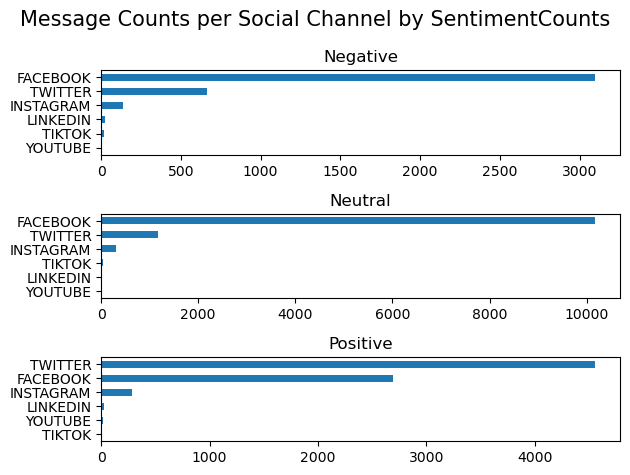

In [19]:
sentiments =  df_Plat['Sentiment'].unique()   #Just getting sentiment attributes(POS,NEG,NEU)
#Plot the graph in message counts
fig, ax = plt.subplots(len(sentiments), 1)

for i, sentiments in enumerate(sentiments):
    df_plot = df_Plat[df_Plat['Sentiment'] == sentiments].sort_values('messages',ascending=True)
    df_plot.plot(kind='barh', x='Social_Channel', y='messages', ax=ax[i], title=sentiments)
    # ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)

fig.suptitle('Message Counts per Social Channel by SentimentCounts', fontsize=15)
fig.tight_layout()
plt.show()


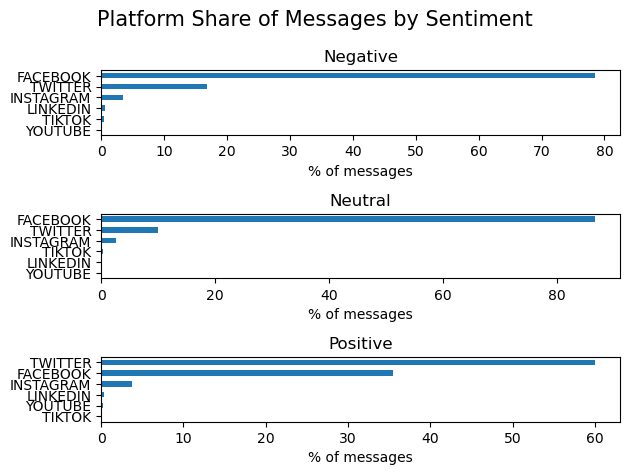

In [20]:
#Want a percentage representation of the above graph

sentiments = df_Plat['Sentiment'].unique()
fig, ax = plt.subplots(len(sentiments), 1)

for i, sentiments in enumerate(sentiments):
    dp_perc = df_Plat[df_Plat['Sentiment'] == sentiments].copy()
    dp_perc['percentage'] = dp_perc['messages'] / dp_perc['messages'].sum() * 100
    dp_perc = dp_perc.sort_values('percentage', ascending=True)
    dp_perc.plot(kind='barh', x='Social_Channel', y='percentage', ax=ax[i], title=sentiments, legend=False)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('% of messages')

fig.suptitle('Platform Share of Messages by Sentiment', fontsize=15)
fig.tight_layout()
plt.show()

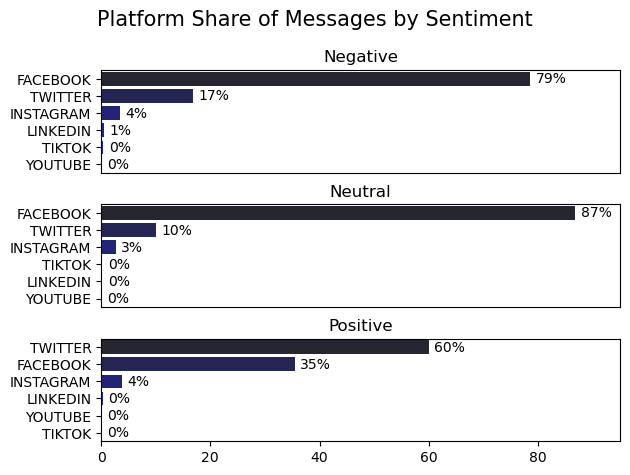

In [21]:
#Want a percentage representation of the above graph

sentiments = df_Plat['Sentiment'].unique()
fig, ax = plt.subplots(len(sentiments), 1)

for i, sentiment in enumerate(sentiments):
    dp_perc = df_Plat[df_Plat['Sentiment'] == sentiment].copy()
    dp_perc['percentage'] = dp_perc['messages'] / dp_perc['messages'].sum() * 100
    dp_perc = dp_perc.sort_values('percentage', ascending=True)
    sns.barplot(data=dp_perc, x='percentage', y='Social_Channel', ax=ax[i], hue='Social_Channel', palette='dark:b_r')
    ax[i].set_title(sentiment)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].invert_yaxis()
    # ax[i].get_legend().remove()
    ax[i].set_xlim(0, 95)
    
    # remove the x-axis tick labels for better readability
    if i != len(sentiments) - 1:
        ax[i].set_xticks([])

    # label the percentage on the bars
    for n, v in enumerate(dp_perc['percentage']):
        ax[i].text(v + 1, n, f'{v:.0f}%', va='center')

fig.suptitle('Platform Share of Messages by Sentiment', fontsize=15)
fig.tight_layout(h_pad=.8)
plt.show()

# ML & Feature engineering

In [22]:
#date cleaning
df_ML = df_sent.copy()
df_ML = df_ML.rename(columns= {'Conversation Stream':'message','snTypeColumn':'channel', 'Created Time': 'date'})
df_ML['date'] = pd.to_datetime(df_ML['date']).dt.date

# Backup
df_backup = df_ML.copy()

In [ ]:
#Balancing the data
def balanced_sample(df, target_n):
    group_col= 'Sentiment'
    
    parts = []
    for value, group in df.groupby(group_col):
        parts.append(group.sample(n=min(len(group), target_n)))
    return pd.concat(parts).reset_index(drop=True)

df_balanced = balanced_sample(df_ML, 3500)
print(df_balanced['Sentiment'].value_counts())


Sentiment
Negative    3500
Neutral     3500
Positive    3500
Name: count, dtype: int64


In [37]:
import re
import html
import emoji
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # 1. Safety check for empty or missing data
    if not isinstance(text, str):
        return ''

    # 2. Fix messy web text (e.g., &#39; to ')
    text = html.unescape(text)

    # 3. Remove URLs and @mentions (we don't want to translate these!)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)

    # 4. PRESERVE EMOJIS: Translate them into words, then remove the colons
    text = emoji.demojize(text)
    text = text.replace(':', ' ')

    # 5. Fix spacing by turning newlines into regular spaces
    text = text.replace('\\n', ' ').replace('\n', ' ')

    # 6. Lowercase everything for consistency
    text = text.lower()

    # 7. Remove junk: Keep only letters and spaces (Emoji text survives this safely!)
    text = re.sub(r'[^a-zA-ZÀ-ÿ\s]', ' ', text)
    
    # 8. Squash double/triple spaces down to a single space
    text = re.sub(r'\s+', ' ', text).strip()

    # 9. Tokenize: Chop the string into individual words
    tokens = word_tokenize(text)

    # 10. Filter & Lemmatize: Remove stop words, drop single letters, and shrink to root words
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 1]

    # 11. Reassemble into a perfectly clean string ready for machine learning
    return ' '.join(tokens)

In [38]:
df_balanced['message_clean'] = df_balanced['message'].apply(clean_text)
df_balanced.head()

,message,date,channel,Sentiment,message_clean
0,I lost mine 2 weeks ago thinking of getting a...,2026-05-23,FACEBOOK,Negative,lost mine week ago thinking getting another
1,Someone explain to me is it possible for us to...,2026-05-23,FACEBOOK,Negative,someone explain possible u told used gb day ai...
2,You see i said at night your network is very b...,2026-05-23,FACEBOOK,Negative,see said night network bad signal everything
3,If it not ohk by today I&#39;m returning it to...,2026-05-21,FACEBOOK,Negative,ohk today returning tomorrow morning go work s...
4,I know am not done paying my airtime advance b...,2026-05-22,FACEBOOK,Negative,know done paying airtime advance please give a...


In [39]:
empty_after_clean = (df_balanced['message_clean'].str.strip() == '').sum()
print(f"{empty_after_clean} rows became empty after cleaning")

822 rows became empty after cleaning


In [40]:
df_balanced = df_balanced[df_balanced['message_clean'].str.strip() != '']

## Vectorization and Training


In [41]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [52]:
# df_balanced.columns.tolist()
# df_balanced[['message', 'message_clean', 'Sentiment']].head()

X_train, X_test, y_train, y_test = train_test_split(        #X being the input data - messages
    df_balanced['message_clean'],
    df_balanced['Sentiment'],
    test_size=0.2,
    stratify=df_balanced['Sentiment'],
    random_state=42
)

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])


In [53]:
# 3. Fit — this runs fit_transform on TF-IDF, then fits the classifier, all in one call
pipeline.fit(X_train, y_train)

# 4. Predict — automatically applies the same fitted TF-IDF transform before predicting
y_pred = pipeline.predict(X_test)

In [54]:
# 5. Evaluate
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       0.80      0.86      0.83       698
     Neutral       0.78      0.77      0.78       581
    Positive       0.96      0.90      0.93       657

    accuracy                           0.85      1936
   macro avg       0.85      0.84      0.85      1936
weighted avg       0.85      0.85      0.85      1936



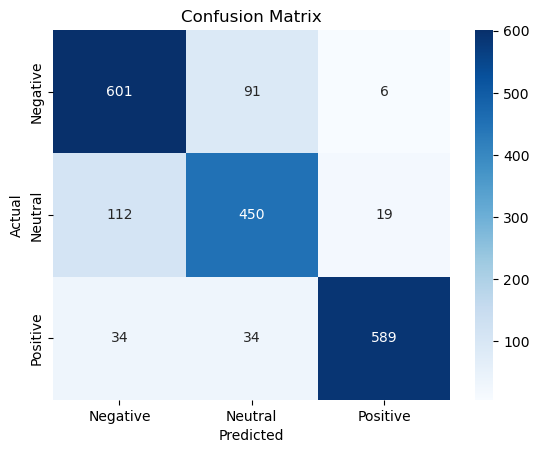

In [55]:
cm = confusion_matrix(y_test, y_pred, labels=pipeline.classes_)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=pipeline.classes_, yticklabels=pipeline.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [50]:
# using Random Forest
from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import GridSearchCV

X_train, X_test, y_train, y_test = train_test_split(        #X being the input data - messages
    df_balanced['message_clean'],
    df_balanced['Sentiment'],
    test_size=0.2,
    stratify=df_balanced['Sentiment'],
    random_state=42
)


pipeline_rf = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
])

# Fit
pipeline_rf.fit(X_train, y_train)

# Predict
y_pred_rf = pipeline_rf.predict(X_test)

# Evaluate
print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

    Negative       0.82      0.85      0.83       698
     Neutral       0.79      0.81      0.80       581
    Positive       0.96      0.90      0.93       657

    accuracy                           0.85      1936
   macro avg       0.86      0.85      0.85      1936
weighted avg       0.86      0.85      0.86      1936



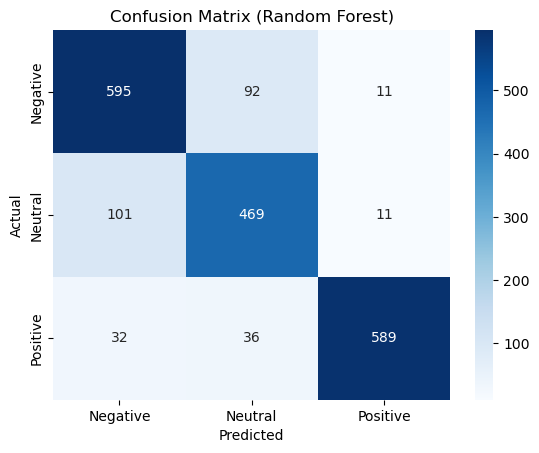

In [51]:
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=pipeline_rf.classes_)
sns.heatmap(cm_rf, annot=True, fmt='d', xticklabels=pipeline_rf.classes_, yticklabels=pipeline_rf.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Random Forest)')
plt.show()

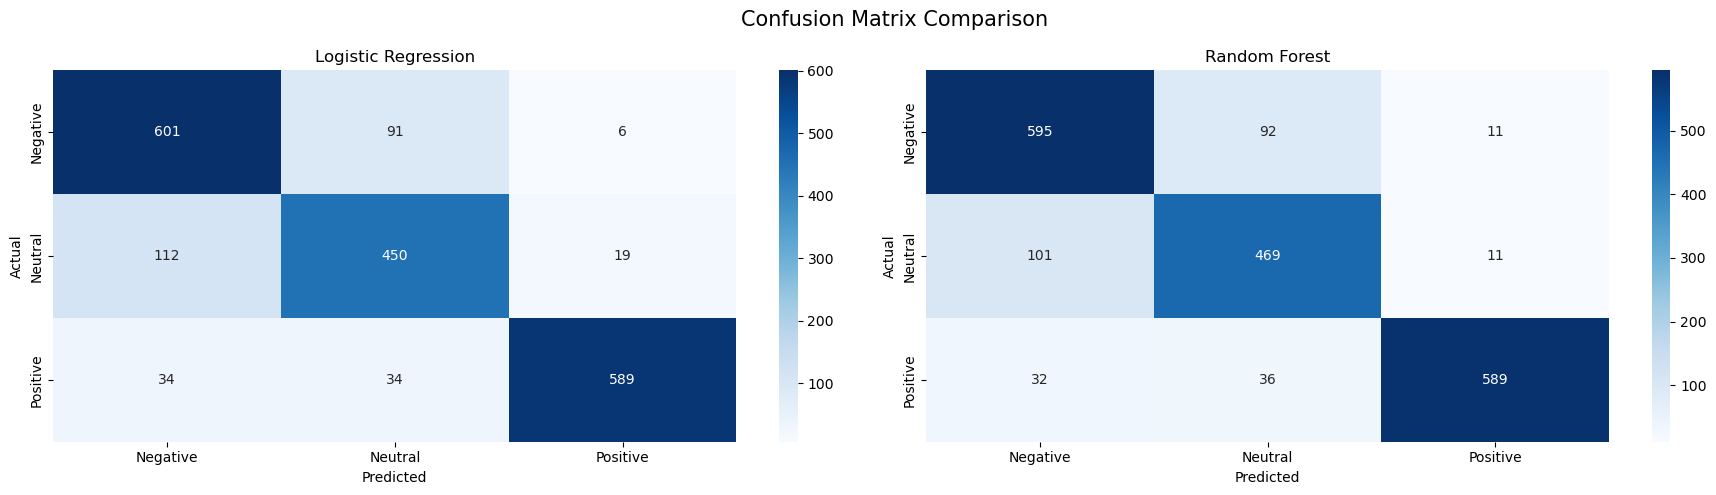

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

models = {
    'Logistic Regression': (pipeline, y_pred),
    'Random Forest': (pipeline_rf, y_pred_rf)
}

for ax, (name, (model, preds)) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, preds, labels=model.classes_)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=model.classes_, yticklabels=model.classes_, ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

fig.suptitle('Confusion Matrix Comparison', fontsize=15)
fig.tight_layout()
plt.show()